# Step 3: MSM construction and validation

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import os
import numpy as np
import pandas as pd

# ----------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.colors import TwoSlopeNorm
import matplotlib as mpl
# ----------------------------------------


# ----------------------------------------
from tqdm.notebook import tqdm  # progress bar 
from deeptime.clustering import KMeans
#import networkx as nx # graph visualization of MSM microstates and macrostates model
# ----------------------------------------


# ----------------------------------------
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
# ----------------------------------------

---
#### Reloading reduced data

In [2]:
tica_lag = 500 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 5
pca_dim_distances = 5
pca_dim_dihedrals = 5


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


#### Iso-contour maps

this takes approx. 3 minutes to run

In [3]:
from scipy.ndimage import gaussian_filter

# ---------------------------------------------------------------------------
# Fast histogram-based smoothed FES
# ---------------------------------------------------------------------------
def compute_fes_fast(
    traj,
    component_x=0,
    component_y=1,
    nbins=100,
    sigma=1.2,
    padding=0.02,
    eps=1e-12
):
    """
    Fast approximation to a KDE free-energy surface.

    Uses a 2D histogram followed by Gaussian smoothing.
    This is much faster than scipy.stats.gaussian_kde for large trajectories.

    Parameters
    ----------
    traj : ndarray, shape (n_frames, n_features)
        Input trajectory/projection.
    component_x, component_y : int
        Components to project onto.
    nbins : int
        Number of bins along each axis.
    sigma : float
        Gaussian smoothing width in bins.
        Larger values give smoother contours.
    padding : float
        Fractional padding added to x/y limits.
    eps : float
        Small floor to avoid log(0).

    Returns
    -------
    xx, yy : ndarray
        Meshgrid of bin centers.
    F : ndarray
        Free energy surface, shifted so min(F)=0.
    """

    x = traj[:, component_x]
    y = traj[:, component_y]

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)

    dx = xmax - xmin
    dy = ymax - ymin

    xmin -= padding * dx
    xmax += padding * dx
    ymin -= padding * dy
    ymax += padding * dy

    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=nbins,
        range=[[xmin, xmax], [ymin, ymax]],
        density=True
    )

    # Smooth the density estimate
    H_smooth = gaussian_filter(H, sigma=sigma)

    # Avoid log(0)
    H_smooth = np.maximum(H_smooth, eps)

    F = -np.log(H_smooth)
    F -= np.nanmin(F)

    # Bin centers
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    xx, yy = np.meshgrid(xcenters, ycenters, indexing="ij")

    return xx, yy, F

In [4]:
nbins_linear = 100

trajectories = [
    tica_distances,
    pca_distances,
    tica_dihedrals,
    pca_dihedrals
]

Fs = []
grids = []

component_x = 0
component_y = 1

for i, traj in enumerate(trajectories):
    print(f"Computing FES for trajectory {trajectories_labels[i]}...")
    xx, yy, F = compute_fes_fast(
        traj,
        component_x=component_x,
        component_y=component_y,
        nbins=nbins_linear
    )
    grids.append((xx, yy))
    Fs.append(F)


Computing FES for trajectory tica_distances...
Computing FES for trajectory pca_distances...
Computing FES for trajectory tica_dihedrals...
Computing FES for trajectory pca_dihedrals...


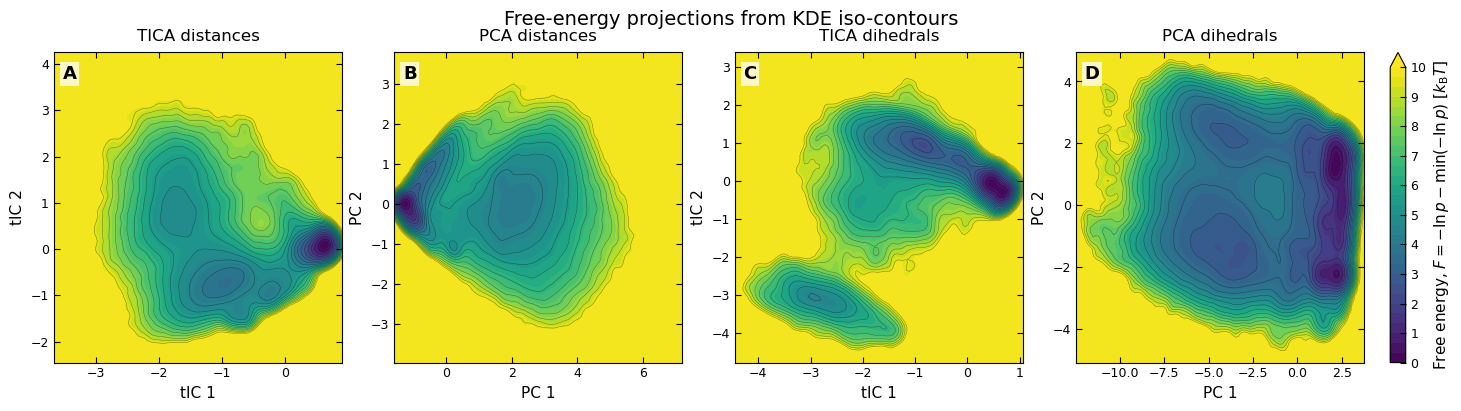

In [5]:
# ---------------------------------------------------------------------------
# Report-quality iso-contour FES plot

# Free energy range
vmin = 0
vmax = 10

# Filled-contour and line-contour levels
levels_filled = np.linspace(vmin, vmax, 31)
levels_lines = np.arange(vmin, vmax + 0.5, 0.5)

# Matplotlib publication settings
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

titles = [
    "TICA distances",
    "PCA distances",
    "TICA dihedrals",
    "PCA dihedrals"
]

xlabels = [
    "tIC 1",
    "PC 1",
    "tIC 1",
    "PC 1"
]

ylabels = [
    "tIC 2",
    "PC 2",
    "tIC 2",
    "PC 2"
]

panel_labels = ["A", "B", "C", "D"]

# ---------------------------------------------------------------------------
# Figure

fig, axes = plt.subplots(
    1, 4,
    figsize=(14.5, 3.8),
    constrained_layout=True
)

axes = axes.flatten()

cmap = "viridis"

for ax, title, xlabel, ylabel, F, (xx, yy), panel in zip(
    axes, titles, xlabels, ylabels, Fs, grids, panel_labels
):
    # Clip high free energies so all panels share the same visual scale
    F_plot = np.clip(F, vmin, vmax)

    im = ax.contourf(
        xx,
        yy,
        F_plot,
        levels=levels_filled,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extend="max"
    )

    ax.contour(
        xx,
        yy,
        F_plot,
        levels=levels_lines,
        colors="k",
        linewidths=0.35,
        alpha=0.45
    )

    ax.set_title(title, pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Panel label
    ax.text(
        0.03,
        0.96,
        panel,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=2.0
        )
    )

    # Better axis appearance
    ax.tick_params(length=4, width=0.8)
    ax.set_aspect("auto")

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)

cbar.set_label(r"Free energy, $F = -\ln p - \min(-\ln p)$ [$k_\mathrm{B}T$]")
cbar.set_ticks(np.arange(vmin, vmax + 1, 1))
cbar.ax.tick_params(length=4, width=0.8)

fig.suptitle(
    "Free-energy projections from KDE iso-contours",
    y=1.04
)

# ---------------------------------------------------------------------------
# Save both raster and vector versions

fig.savefig(
    "../output_figures/free_energy_projection_report.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/free_energy_projection_report.pdf",
    bbox_inches="tight"
)

plt.show()

---
### performing kmeans clustering + msm transition matrix estimation + implied timescales test

Running KMeans with 10 clusters...


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

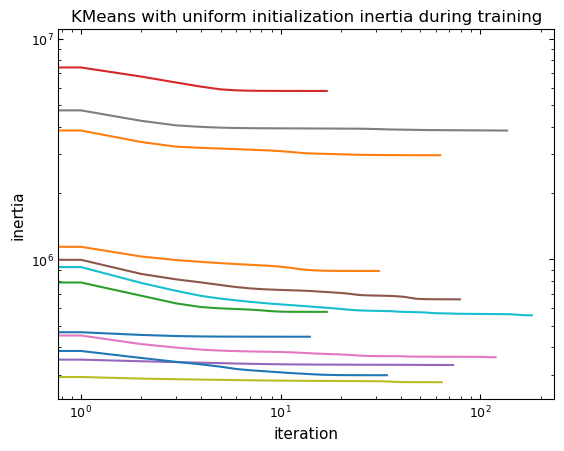

In [ ]:
kcluster_list = [10, 20, 30]

run_kmeans = False # avoid rerunning accidentantly as it takes a long time

if run_kmeans:

    for n_clusters in kcluster_list:
        print(f"Running KMeans with {n_clusters} clusters...")
        kmeans = KMeans(
            n_clusters=n_clusters,
            init_strategy='kmeans++',
            max_iter=200,
            fixed_seed=13,
            n_jobs=8,
            progress=tqdm
        )
        for i, traj in enumerate(trajectories):
            traj_name = trajectories_labels[i]
            kmeans.fit(traj)
            discretized_trajectories = kmeans.transform(traj)
            model = kmeans.fetch_model() # fetches the latest model, containing all important information
            plt.loglog(model.inertias)
            plt.xlabel("iteration")
            plt.ylabel("inertia")
            plt.title("KMeans with uniform initialization inertia during training")

            np.savez(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}", traj = discretized_trajectories, centers = model.cluster_centers)

In [7]:
"""
n_clu_for_plot = 100

feature_names = ["distances", "dihedrals"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        centers = data["centers"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")
        if i == len(trajectories_labels) - 1:
                axes[-1], im = pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[-1], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
                plt.colorbar(im, ax=axes[-1])
        else:
                pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[i], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
        axes[i].scatter(centers[:, 0], centers[:, 1], s=0.4, alpha=1, color = "white",  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


# Plot assignments

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        assignments = data["traj"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")
        axes[i].scatter(dtraj[:, 0][::10], dtraj[:, 1][::10], c = assignments[::10], cmap = "tab20", s=0.4, alpha=1,  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()
"""

'\nn_clu_for_plot = 100\n\nfeature_names = ["distances", "dihedrals"]\nfig, axes = plt.subplots(1, 4, figsize=(15, 3))\naxes = axes.flatten()\nfor i, (traj_name) in enumerate(trajectories_labels):\n        data = np.load(f"../intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")\n        centers = data["centers"]\n        method = traj_name.split("_")[0]\n        dtraj = np.load(f"../intermediate_outputs/dimred/{traj_name}.npy")\n        if i == len(trajectories_labels) - 1:\n                axes[-1], im = pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[-1], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")\n                plt.colorbar(im, ax=axes[-1])\n        else:\n                pu.plot_free_energy_projection(dtraj, 0, 1, ax = axes[i], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")\n        axes[i].scatter(centers[:, 0], centers[:, 1], s=0.4, alpha=1, color = "white",  label = traj_name)\n\nplt.subplots_adjus

---

In [8]:
lagtimes = np.arange(100, 2000, 100) # lag times in frames (10 frames = 2 nanoseconds, 5000 frames = 1 microsecond)



df = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [trajectories_labels, kcluster_list, lagtimes],
        names=["Trajectory", "N_clusters", "Lag"]
    ),
    columns=[f"Timescale_{i}" for i in range(1, 11)],
    dtype=float
)

for n_clusters in kcluster_list:
    for traj_name in trajectories_labels:

        data = np.load(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}.npz")
        dtraj = data["traj"]
        populated_clusters = np.unique(dtraj)

        for lag in lagtimes:
            tce = TransitionCountEstimator(
                lagtime=lag,
                count_mode="sliding-effective"
            )
            C = tce.fit(dtraj).fetch_model()
            submodel = C.submodel_largest(connectivity_threshold=1., directed=True)
            df.loc[(traj_name, n_clusters, lag), "llc"] = submodel.n_states/n_clusters # size of largest connected component (llc) as a fraction of total number of clusters

            msm = MaximumLikelihoodMSM(reversible = True).fit(C).fetch_model()
            its = msm.timescales(k=10)
            cols = [f"Timescale_{i}" for i in range(1, len(its) + 1)]
            df.loc[(traj_name, n_clusters, lag), cols] = its
            df.to_csv("../intermediate_outputs/implied_timescales.csv", mode = "w", header = True)
            df.head()

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_54496/2618869528.py:28: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), "llc"] = submodel.n_states/n_clusters # size of largest connected component (llc) as a fraction of total number of clusters
/Users/miriamzara/miniconda3/envs/MSM_env/lib/python3.11/site-packages/deeptime/markov/tools/analysis/_api.py:256: UserWarning: truncated eigendecomposition to contain 10 components
  warnings.warn('truncated eigendecomposition to contain %s components' % new_k, category=UserWarning)
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_54496/2618869528.py:28: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), "llc"] = submodel.n_states/n_clusters # size of largest connected component (llc) as a fraction of total number of clusters
/Users/miriamzara/miniconda3/envs/MSM_env/lib/python3.11/site-packages/deeptime

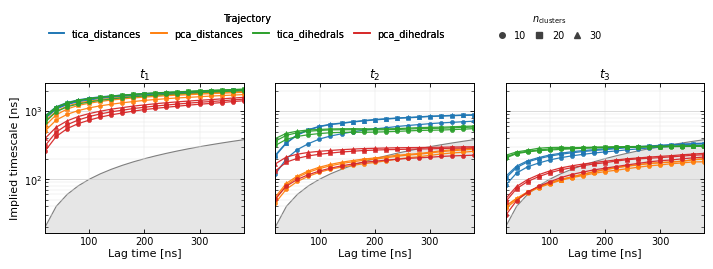

In [9]:
from matplotlib.ticker import LogLocator, NullFormatter

# --------------------------------
# Report-style settings
# --------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "savefig.dpi": 300,
})

# --------------------------------
# Load and clean data
# --------------------------------
df = pd.read_csv(
    "../intermediate_outputs/implied_timescales.csv",
    index_col=[0, 1, 2]
)

df.index.names = ["Trajectory", "N_clusters", "Lag"]

df = (
    df.reset_index()
      .drop_duplicates(
          subset=["Trajectory", "N_clusters", "Lag"],
          keep="last"
      )
)

# Convert lag and implied timescales to ns
df["Lag"] = df["Lag"].astype(float) * time_step_nanos

timescale_cols = [
    col for col in df.columns
    if col.startswith("Timescale_")
]

for col in timescale_cols:
    df[col] = df[col].astype(float) * time_step_nanos

# --------------------------------
# Plot settings
# --------------------------------
n_timescales_to_plot = 3

trajectories__ = list(df["Trajectory"].unique())
n_clusters_values = sorted(df["N_clusters"].unique())

# Encoding:
# color = trajectory
# marker = n_clusters
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
traj_to_color = {
    traj: color_cycle[i % len(color_cycle)]
    for i, traj in enumerate(trajectories__)
}

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
cluster_to_marker = {
    n_clusters: markers[i % len(markers)]
    for i, n_clusters in enumerate(n_clusters_values)
}

# Lag values for diagonal reference
lag_values = np.sort(df["Lag"].unique())
lag_min = lag_values.min()
lag_max = lag_values.max()

# Positive finite values only for log-scale y limits
all_ts_values = df[
    [f"Timescale_{i}" for i in range(1, n_timescales_to_plot + 1)]
].to_numpy(dtype=float)

positive_ts = all_ts_values[np.isfinite(all_ts_values) & (all_ts_values > 0)]

ymin = max(0.8 * min(lag_min, positive_ts.min()), 1e-3)
ymax = 1.25 * positive_ts.max()

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    nrows=1,
    ncols=n_timescales_to_plot,
    figsize=(7.2, 2.6),
    sharex=True,
    sharey=True
)

if n_timescales_to_plot == 1:
    axs = np.array([axs])

for i, ax in enumerate(axs, start=1):

    # Unresolved region: t_i < tau
    ax.fill_between(
        lag_values,
        ymin,
        lag_values,
        color="0.90",
        zorder=0
    )

    # Reference line: t_i = tau
    ax.plot(
        lag_values,
        lag_values,
        color="0.45",
        lw=0.8,
        alpha=0.9,
        zorder=1
    )

    for traj in trajectories__:
        for n_clusters in n_clusters_values:

            sub = df[
                (df["Trajectory"] == traj)
                & (df["N_clusters"] == n_clusters)
            ].sort_values("Lag")

            if sub.empty:
                continue

            ycol = f"Timescale_{i}"

            ax.plot(
                sub["Lag"],
                sub[ycol],
                color=traj_to_color[traj],
                marker=cluster_to_marker[n_clusters],
                lw=0.9,
                ms=3.0,
                markeredgewidth=0.4,
                alpha=0.95,
                label=f"{traj}, {n_clusters}"
            )

    ax.set_title(rf"$t_{i}$", pad=3)
    ax.set_xlabel("Lag time [ns]", labelpad=2)

    ax.set_yscale("log")
    ax.set_xlim(lag_min, lag_max)
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(
        LogLocator(base=10, subs=np.arange(2, 10) * 0.1)
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(axis="y", which="major", color="0.82", lw=0.55)
    ax.grid(axis="y", which="minor", color="0.90", lw=0.35)
    ax.grid(axis="x", which="major", color="0.90", lw=0.35)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        width=0.6,
        length=3,
        pad=2
    )
    ax.tick_params(
        axis="both",
        which="minor",
        width=0.45,
        length=2
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)

axs[0].set_ylabel("Implied timescale [ns]", labelpad=3)

# --------------------------------
# Build clean two-part legend
# --------------------------------
trajectory_handles = [
    plt.Line2D(
        [0], [0],
        color=traj_to_color[traj],
        lw=1.2,
        label=str(traj)
    )
    for traj in trajectories__
]

cluster_handles = [
    plt.Line2D(
        [0], [0],
        color="0.25",
        marker=cluster_to_marker[n_clusters],
        lw=0,
        ms=4,
        label=str(n_clusters)
    )
    for n_clusters in n_clusters_values
]

legend_1 = fig.legend(
    handles=trajectory_handles,
    title="Trajectory",
    loc="upper center",
    bbox_to_anchor=(0.36, 1.08),
    ncol=min(len(trajectories__), 4),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.6,
    columnspacing=1.0
)

legend_2 = fig.legend(
    handles=cluster_handles,
    title=r"$n_\mathrm{clusters}$",
    loc="upper center",
    bbox_to_anchor=(0.78, 1.08),
    ncol=min(len(n_clusters_values), 6),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.0,
    columnspacing=0.8
)

fig.add_artist(legend_1)

fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.20,
    top=0.78,
    wspace=0.16
)

fig.savefig(
    "../output_figures/implied_timescales_report.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/implied_timescales_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_54496/3020052605.py:63: PerformanceWarning: indexing past lexsort depth may impact performance.
  sub = df.loc[(traj_name, n_clusters)].sort_index()


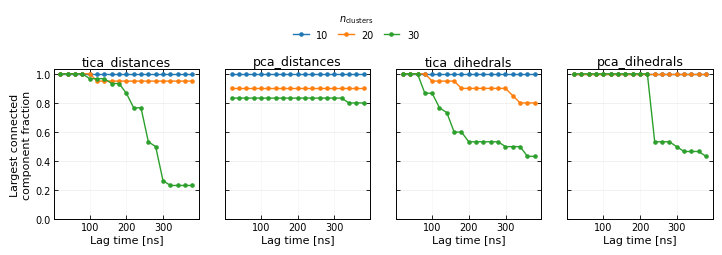

In [10]:
# --------------------------------
# Report-style settings
# --------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "savefig.dpi": 300,
})

# --------------------------------
# Input assumptions
# df has MultiIndex: (traj_name, n_clusters, lag)
# df has column: "llc"
# --------------------------------
df = pd.read_csv(
    "../intermediate_outputs/implied_timescales.csv",
    index_col=[0, 1, 2]
)

df.index.names = ["traj_name", "n_clusters", "lag"]
traj_names = list(df.index.get_level_values("traj_name").unique())
n_clusters_values = sorted(df.index.get_level_values("n_clusters").unique())

n_panels = len(traj_names)

# --------------------------------
# Figure size
# Good for one-column-wide row of panels in report.
# If n_panels = 4, this gives ~7.2 x 2.5 in.
# --------------------------------
fig_width = 7.2
fig_height = 2.5 if n_panels <= 4 else 3.0

fig, axs = plt.subplots(
    nrows=1,
    ncols=n_panels,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True
)

if n_panels == 1:
    axs = np.array([axs])

# --------------------------------
# Plot
# --------------------------------
for panel_id, (ax, traj_name) in enumerate(zip(axs, traj_names)):

    for n_clusters in n_clusters_values:

        # Skip missing combinations
        try:
            sub = df.loc[(traj_name, n_clusters)].sort_index()
        except KeyError:
            continue

        lag_time_ns = np.asarray(sub.index, dtype=float) * time_step_nanos

        ax.plot(
            lag_time_ns,
            sub["llc"].to_numpy(),
            marker="o",
            lw=1.0,
            ms=2.8,
            markeredgewidth=0.4,
            label=f"{n_clusters}"
        )

    ax.set_title(str(traj_name), pad=3)
    ax.set_xlabel("Lag time [ns]", labelpad=2)

    ax.grid(axis="y", alpha=0.25, lw=0.5)
    ax.grid(axis="x", alpha=0.15, lw=0.4)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        width=0.6,
        length=3,
        pad=2
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)


axs[0].set_ylabel("Largest connected\ncomponent fraction", labelpad=3)

# If llc is a fraction, keep the same y-scale for all panels
axs[0].set_ylim(0.0, 1.03)

# --------------------------------
# Shared legend outside the panels
# --------------------------------
handles, labels = axs[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title=r"$n_\mathrm{clusters}$",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=min(len(n_clusters_values), 6),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.6,
    columnspacing=1.0
)

fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.22,
    top=0.82,
    wspace=0.18
)

fig.savefig(
    "../output_figures/largest_connected_component_vs_lag.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/largest_connected_component_vs_lag.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of clusters was chosen as $50$ as this gives the largest connected set with respect to the graph size.

In [ ]:
msm_lag_ns = 20
msm_lag = int(msm_lag_ns / time_step_nanos) # 20 ns
n_clusters = 50
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")

msm_dict = {}
cluster_centers_dict = {} # cluster idx to microstate idx
micro_trajectory_dict = {} # traj -> micro traj
clean_micro_trajectory_dict = {} # traj -> micro traj

for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(connectivity_threshold=1., directed=True)

    #cluster_centers_dict[name] = submodel.transform_discrete_trajectories_to_submodel(np.arange(n_clusters))
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{msm_lag}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    clean_micro_trajectory_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)

    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

In [30]:
for name, msm in msm_dict.items():
    print("Name: {}, active states: {}".format(name, msm.n_states))

Name: tica_distances, active states: 20
Name: pca_distances, active states: 38
Name: tica_dihedrals, active states: 29
Name: pca_dihedrals, active states: 50


# CK test 

In [ ]:
n_clusters = 50
lagtime_frames = 2000

# Run CK test
vamp_models = [(lagtime=lag, observable_transform=model).fit_fetch(data) for lag in tqdm(lagtimes)]

---
#### Visualization of the free energy $-\ln{\pi}$

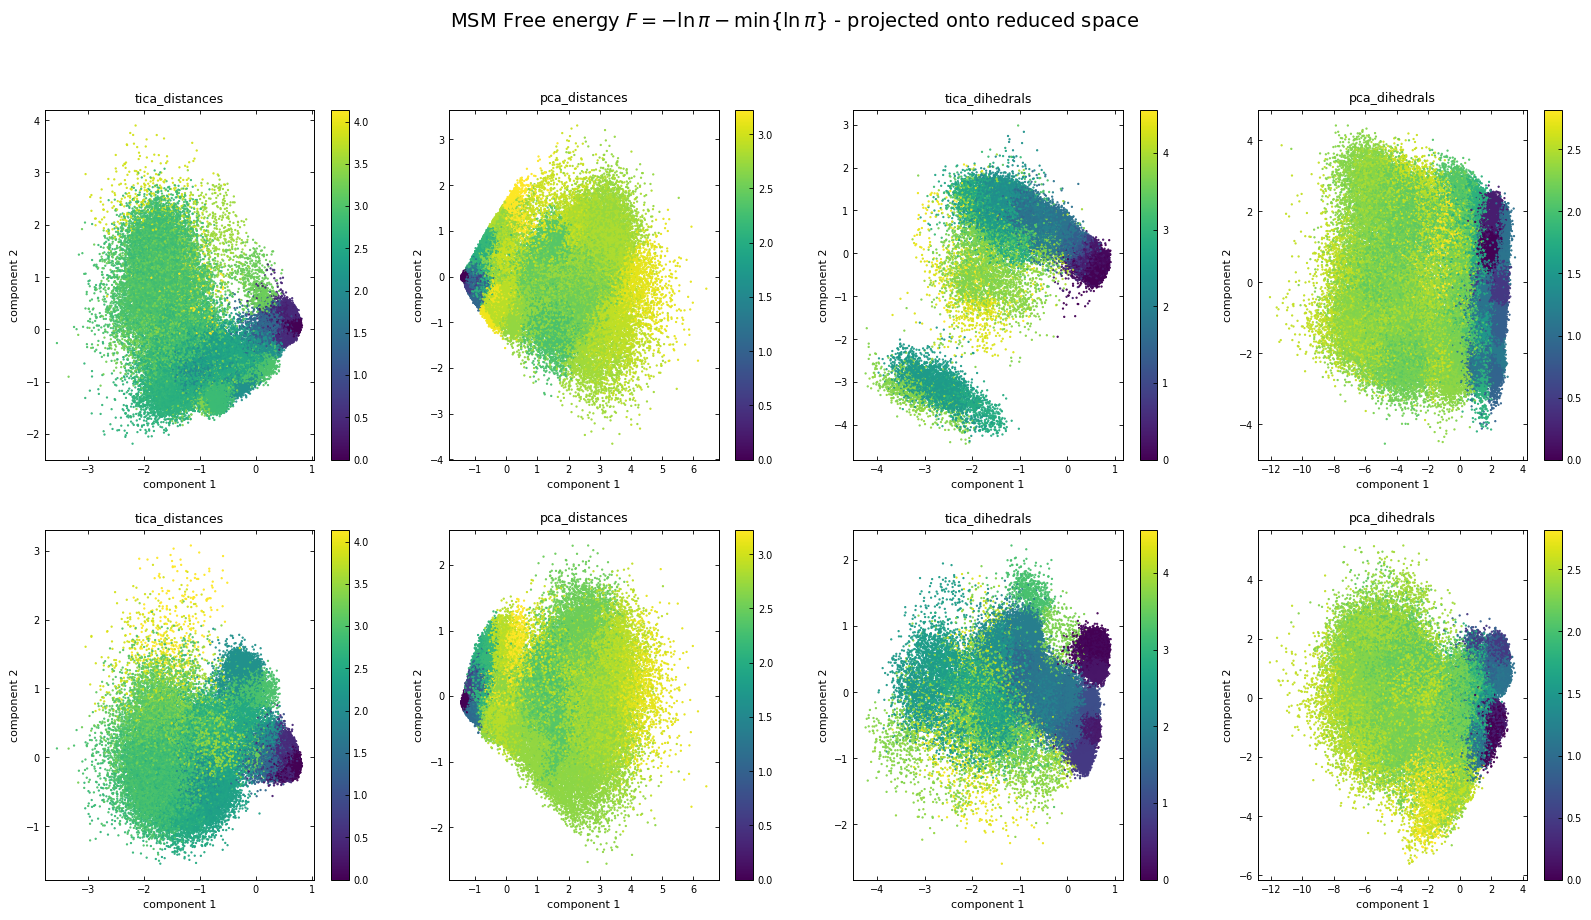

In [15]:
fig, axs = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))


for i, name in enumerate(trajectories_labels):

    traj = micro_trajectory_dict[name]
    pi = msm_dict[name].stationary_distribution

    # transform  to free energy
    F = np.full_like(pi, np.nan)
    mask = pi > 0
    F[mask] = -np.log(pi[mask])
    F -= np.nanmin(F)

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = F[traj[mask]]



    ax = axs[0, i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


    ax = axs[1, i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 3][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


plt.suptitle(r"MSM Free energy $F = -\ln{\pi} - \min\{{\ln{\pi}}\}$ - projected onto reduced space")   
plt.show()

---
###  Validation of the microstate model: autocorrelation test (RMSD)

Lets call $\theta (\vec{x})$ an observable of the molecular trajectory.
- Construct the vector of observables $\mathbf{\theta} = (\theta_1, \, \theta_N)$ containing the value of the observable $\theta$ in each markov microstate.


    0. For each cluster center, I take the state closest to the cluster center as the representative state of the markov microstate;
    1. For each representative state, extract its temporal frame index and use it to retrieve the corresponding value of the RMSD from the crystal structure.

- Compute the model predicted autocorrelation according to:

$$
ACF_\theta(k) = \frac{\sum_{i=1}^{N}\, \lambda_i^k\, \langle\mathbf{\theta}, \mathbf{r_i} \rangle^2}{\sum_{i=1}^{N}\, \langle\mathbf{\theta}, \mathbf{r_i}\rangle^2}
$$

where the $\mathbf{r}_i$ are the right eigenvectors of the transition matrix.

- Compare with the empirical autocorrelation.

In [19]:
from scipy.signal import correlate
from deeptime.markov.tools.analysis import correlation


def get_empirical_autocorrelation(obs):
    obs = obs - obs.mean()
    acf = correlate(obs, obs, mode="full")
    acf = acf[acf.size // 2:]      # keep non-negative lags
    acf /= acf[0]                  # normalize so acf[0] = 1
    return acf


def get_msm_autocorrelation(obs, msm, times_array):
    """
    obs: array of observables, one for each microstate
    msm: object of the class deeptime::MarkovStateModelCollection
    """
    # center the observable using the stationary distribution
    obs_mean = np.dot(msm.stationary_distribution, obs)
    obs = obs - obs_mean
    variance = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=(0,), 
                                k=None, 
                                ncv=None)[0]
    
    times_array_in_units_of_tau = np.array(times_array / msm.lagtime, dtype = int)
    acf = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=times_array_in_units_of_tau, 
                                k=None, 
                                ncv=None)
    
    return acf/variance


crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)


crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)
RMSD_timeseries = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

theta_dict = {} # one array of observables per each msm model

for i, name in enumerate(trajectories_labels):
    traj = micro_trajectory_dict[name]
    msm = msm_dict[name]
    theta_array = np.ones(msm.n_states)  * (-1)
    for j in np.arange(0, msm.n_states):
        representative_frames = np.where(traj == j)[0]
        RMSD_values = RMSD_timeseries[representative_frames]
        theta_array[j] = np.mean(RMSD_values)
    theta_dict[name] = theta_array


empirical_acf = get_empirical_autocorrelation(RMSD_timeseries)



max_time = 100000 # in frames, corresponds to 20 microseconds
print("Max time for ACF (frames)", max_time)
print("Max time for ACF (nanoseconds)", max_time * time_step_nanos) # 20 microseconds
model_acf_dict = {}
for name in trajectories_labels:
    theta_array = theta_dict[name]
    model_acf_dict[name] = get_msm_autocorrelation(theta_dict[name], msm_dict[name], times_array=np.arange(0, max_time)) 

Max time for ACF (frames) 100000
Max time for ACF (nanoseconds) 19986.35685410811


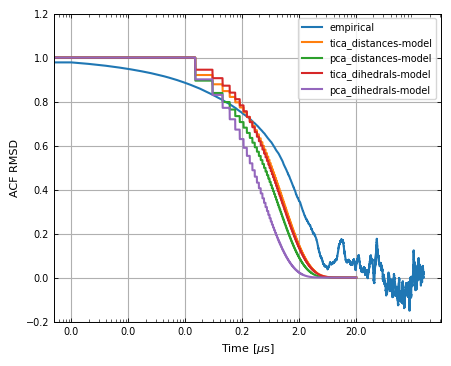

In [20]:
fig, ax = plt.subplots(figsize = (5,4))


ax.plot(np.arange(len(empirical_acf)), empirical_acf, label = "empirical")
for name in trajectories_labels:
    model_acf = model_acf_dict[name]
    ax.plot(np.arange(len(model_acf)), model_acf, label = f"{name}-model")

ax.set_xscale("log", base=10)
# ticks at powers of 10 frames
xticks = [1, 10, 100, 1000, 10000, 100000]
xticks = [x for x in xticks if x < len(empirical_acf)]
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x*time_step_micros:.1f}" for x in xticks])

ax.legend()
ax.set_ylabel("ACF RMSD")
ax.set_xlabel(f"Time [$\mu$s]")
ax.grid()
plt.ylim(-0.2, 1.2)
plt.show()

---

## Spectral analysis of the microstate model

# ----

In [ ]:
# Plot 1-Q for reference, and msm leading three eigenvectors
# (row stochastic convention -> look at the *right* eigenvectors)

RMSD_timeseries = np.load("../intermediate_outputs/RMSD_crystal_nm.npy")
z_timeseries = RMSD_timeseries - RMSD_timeseries.min()
z_timeseries = z_timeseries / z_timeseries.max() # now ranges from 0 to 1

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))

for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_timeseries[::10], cmap = "RdBu_r", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label="RMSD (normalized)")
    #else:
    #    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"RMSD to crystal structure - projected onto reduced space")     
plt.show()

In [ ]:
Q_timeseries = np.load("../intermediate_outputs/Q_timeseries_all.npy")


fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))

for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = Q_timeseries[::10], cmap = "RdBu_r", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label="Fraction of native contacts")
    #else:
        #plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"Fraction of native contacts Q - projected onto reduced space")     
plt.show()

In [ ]:
# Plotting the first three eigenvectors of the MSMs
eigvecs_to_plot = 1

fig, axs = plt.subplots(
    nrows=eigvecs_to_plot,
    ncols=4,
    figsize=(20, 5 * eigvecs_to_plot),
    squeeze=False,  # always return a 2D array
)


for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    #R = msm.eigenvectors_right(k=eigvecs_to_plot + 1)[:, 1:] # skip the first one which is np.ones

    L = msm.eigenvectors_left(k=eigvecs_to_plot+1)[1:, :].T # includes the first one which is np.ones, but we will plot it as well for reference
    # renormalize each eigenvector to range approximately from -1 to 1 for better visualization
    #R_normalized = R / np.abs(R).max(axis=0)
    L_normalized = L / np.abs(L).max(axis=0)


    traj = micro_trajectory_dict[name]
    # transform  to eigvec values
    z_values = np.full((len(traj), eigvecs_to_plot), np.nan)
    mask = traj != -1
    #z_values[mask] = R_normalized[traj[mask], :eigvecs_to_plot]
    z_values[mask] = L_normalized[traj[mask], :eigvecs_to_plot]

    xy = trajectories[i]

    for row in range(eigvecs_to_plot):
        ax = axs[row, i]
        #ax = axs[i]
        norm = TwoSlopeNorm(vcenter=0.0)
        
        ax.scatter(xy[:, 0][::10], xy[:, 1][::10], c = z_values[::10, row], norm = norm, cmap = "PiYG", s=0.4, alpha=1)
        if i == len(trajectories_labels) - 1:
            plt.colorbar(ax.collections[0], ax=ax, label=f"Eigenvector {row+1} value")
        else:
            plt.colorbar(ax.collections[0], ax=ax)
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.set_title(f"{name}")    

---

In [44]:
from deeptime.util.validation import implied_timescales, ck_test
from deeptime.plots import plot_implied_timescales, plot_ck_test


# Lag times in frames
lagtimes = np.arange(10, 2000, 20)

n_clusters_list = [50]
n_its = 10

# Store numerical results
df = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [trajectories_labels, n_clusters_list, lagtimes],
        names=["Trajectory", "N_clusters", "Lag"]
    ),
    columns=["llc"] + [f"Timescale_{i}" for i in range(1, n_its + 1)],
    dtype=float
)

# Store MSMs for deeptime plotting
msm_lagtime_models = {
    traj_name: {
        lag: []
        for lag in lagtimes
    }
    for traj_name in trajectories_labels
}

# Store actually successful lagtimes, in case some models fail
successful_lagtimes = {
    traj_name: {
        lag: []
        for lag in lagtimes
    }
    for traj_name in trajectories_labels
}

for n_clusters in n_clusters_list:
    for traj_name in trajectories_labels:

        print(f"\nTrajectory: {traj_name}, N_clusters: {n_clusters}")

        data = np.load(
            f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}.npz"
        )
        dtraj = data["traj"].astype(int)

        for lag in lagtimes:
            print(f"  lag = {lag}")

            try:
                tce = TransitionCountEstimator(
                    lagtime=int(lag),
                    count_mode="sliding-effective"
                )

                C = tce.fit(dtraj).fetch_model()

                submodel = C.submodel_largest(
                    connectivity_threshold=1.0,
                    directed=True
                )

                df.loc[(traj_name, n_clusters, lag), "llc"] = (
                    submodel.n_states / n_clusters
                )

                msm = MaximumLikelihoodMSM(
                    reversible=True
                ).fit(C).fetch_model()

                # Store model for deeptime ITS plotting
                msm_lagtime_models[traj_name][lag].append(msm)
                successful_lagtimes[traj_name][lag].append(lag)

                # Store timescales numerically
                timescales = msm.timescales(k=n_its)

                for j, ts in enumerate(timescales, start=1):
                    df.loc[(traj_name, n_clusters, lag), f"Timescale_{j}"] = ts

            except Exception as err:
                print(f"    failed at lag={lag}: {err}")

# Save once at the end, not inside the inner loop
df.to_csv("../intermediate_outputs/implied_timescales_prova.csv")


Trajectory: tica_distances, N_clusters: 50
  lag = 10
  lag = 30
  lag = 50
  lag = 70
  lag = 90
  lag = 110
  lag = 130
  lag = 150
  lag = 170
  lag = 190


/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_38471/1925179526.py:65: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), "llc"] = (
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_38471/1925179526.py:81: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), f"Timescale_{j}"] = ts


  lag = 210
  lag = 230
  lag = 250
  lag = 270
  lag = 290
  lag = 310
  lag = 330
  lag = 350
  lag = 370
  lag = 390
  lag = 410
  lag = 430
  lag = 450
  lag = 470
  lag = 490
  lag = 510
  lag = 530
  lag = 550
  lag = 570
  lag = 590
  lag = 610
  lag = 630
  lag = 650
  lag = 670
  lag = 690
  lag = 710
  lag = 730
  lag = 750
  lag = 770
  lag = 790
  lag = 810
  lag = 830
  lag = 850
  lag = 870
  lag = 890
  lag = 910
  lag = 930
  lag = 950
  lag = 970
  lag = 990
  lag = 1010
  lag = 1030
  lag = 1050
  lag = 1070
  lag = 1090
  lag = 1110
  lag = 1130
  lag = 1150
  lag = 1170
  lag = 1190
  lag = 1210
  lag = 1230
  lag = 1250
  lag = 1270
  lag = 1290
  lag = 1310
  lag = 1330
  lag = 1350
  lag = 1370
  lag = 1390
  lag = 1410
  lag = 1430
  lag = 1450
  lag = 1470
  lag = 1490
  lag = 1510
  lag = 1530
  lag = 1550
  lag = 1570
  lag = 1590
  lag = 1610
  lag = 1630
  lag = 1650
  lag = 1670
  lag = 1690
  lag = 1710
  lag = 1730
  lag = 1750
  lag = 1770
  lag = 1790


Skipping state set [2] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [3] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [9] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [13] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [14] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [18] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [29] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [30] due to error in estimation: Some row and corresponding column of the count matrix C have z

  lag = 1870
  lag = 1890
  lag = 1910
  lag = 1930
  lag = 1950
  lag = 1970
  lag = 1990

Trajectory: pca_distances, N_clusters: 50
  lag = 10
  lag = 30


...

  lag = 1810
  lag = 1830
  lag = 1850
  lag = 1870


Skipping state set [29] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [30] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [37] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [41] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [42] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [2] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [3] due to error in estimation: Some row and corresponding column of the count matrix C have 

  lag = 1890
  lag = 1910
  lag = 1930
  lag = 1950


Skipping state set [37] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [41] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [42] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [2] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [3] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [9] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [13] due to error in estimation: Some row and corresponding column of the count matrix C have z

  lag = 1970
  lag = 1990

Trajectory: tica_dihedrals, N_clusters: 50
  lag = 10
  lag = 30
  lag = 50
  lag = 70
  lag = 90
  lag = 110
  lag = 130
  lag = 150
  lag = 170
  lag = 190
  lag = 210
  lag = 230
  lag = 250
  lag = 270
  lag = 290
  lag = 310
  lag = 330
  lag = 350
  lag = 370
  lag = 390
  lag = 410
  lag = 430
  lag = 450
  lag = 470
  lag = 490
  lag = 510
  lag = 530
  lag = 550
  lag = 570
  lag = 590
  lag = 610
  lag = 630
  lag = 650
  lag = 670
  lag = 690
  lag = 710
  lag = 730
  lag = 750
  lag = 770
  lag = 790
  lag = 810
  lag = 830
  lag = 850
  lag = 870
  lag = 890
  lag = 910
  lag = 930
  lag = 950
  lag = 970
  lag = 990
  lag = 1010
  lag = 1030
  lag = 1050
  lag = 1070
  lag = 1090
  lag = 1110
  lag = 1130
  lag = 1150
  lag = 1170
  lag = 1190
  lag = 1210
  lag = 1230
  lag = 1250
  lag = 1270
  lag = 1290
  lag = 1310
  lag = 1330
  lag = 1350
  lag = 1370
  lag = 1390
  lag = 1410
  lag = 1430
  lag = 1450
  lag = 1470
  lag = 1490
  lag = 15

AssertionError: all models need to have a timescales method

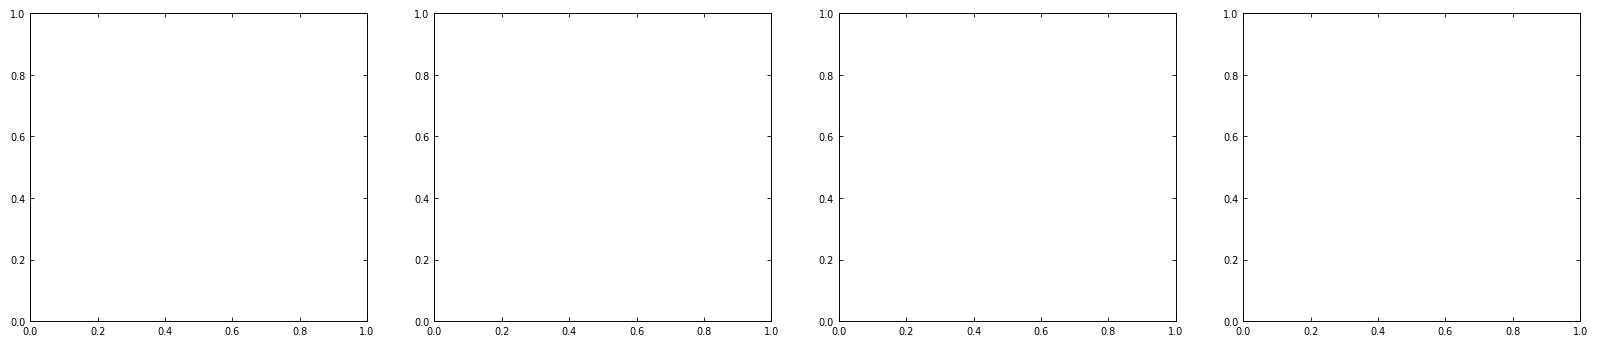

In [47]:
fig, axs = plt.subplots(
    ncols=len(trajectories_labels),
    figsize=(5 * len(trajectories_labels), 4 * len(n_clusters_list)),
    squeeze=False,
    sharex=False,
    sharey=False
)

for col, traj_name in enumerate(trajectories_labels):

    ax = axs[col]

    models = [msm_lagtime_models[traj_name][lag] for lag in lagtimes if msm_lagtime_models[traj_name][lag]]


    if len(models) == 0:
        ax.set_title(f"{traj_name}")
        ax.axis("off")
        continue

    its_data = implied_timescales(
        models,
        n_its=n_its
    )

    plot_implied_timescales(
        its_data,
        n_its=n_its,
        ax=ax
    )

    ax.set_title(f"{traj_name}, {n_clusters} clusters")
    ax.set_xlabel("Lag time / frames")
    ax.set_ylabel("Implied timescale / frames")

plt.tight_layout()
plt.show()


CK test for tica_distances, 150 clusters

CK test for pca_distances, 150 clusters

CK test for tica_dihedrals, 150 clusters

CK test for pca_dihedrals, 150 clusters


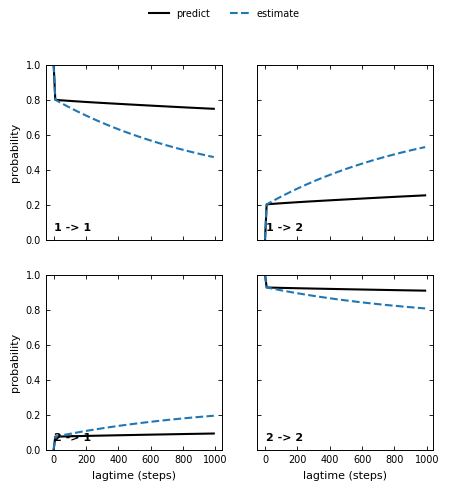

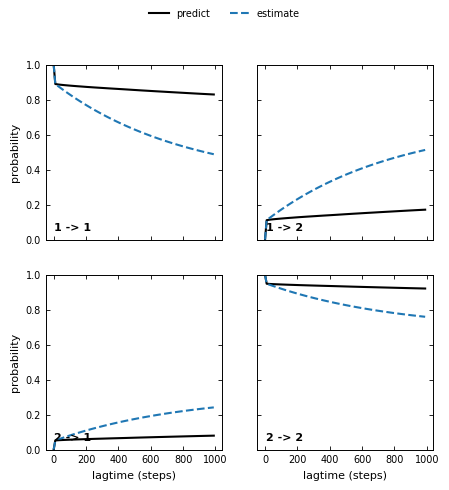

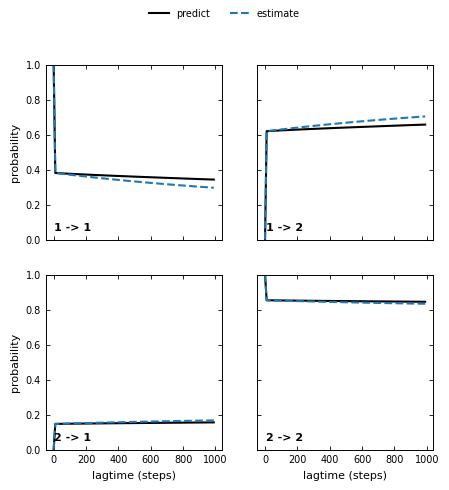

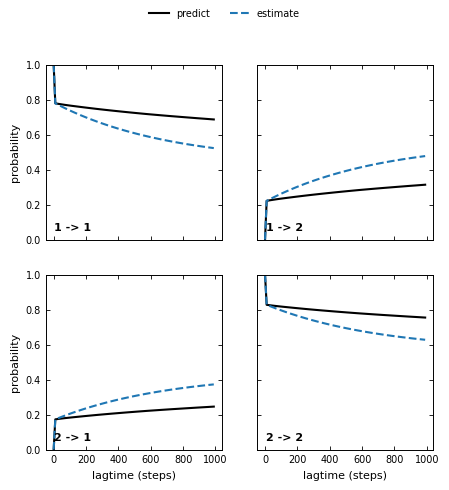

In [ ]:
for traj_name in trajectories_labels:

    models = msm_lagtime_models[traj_name][n_clusters_list[0]]  # Use the first n_clusters value for CK test

    if len(models) == 0:
        print(f"No valid models for {traj_name}, {n_clusters_list[0]} clusters")
        continue

    print(f"\nCK test for {traj_name}, {n_clusters_list[0]} clusters")

    plot_ck_test(models[0].ck_test(models, n_metastable_sets = 2))